# Model Building and Training — Fraud Detection

**Project:** Improved Detection of Fraud Cases — Adey Innovations Inc.
**Task:** Task 2 — Model Building and Training
**Datasets:** `fraud_data_clean.csv` | `creditcard.csv` (processed splits)

---

## Objectives

1. Load preprocessed train/test splits for both datasets.
2. Train a Logistic Regression baseline model.
3. Train a Random Forest ensemble model with hyperparameter tuning.
4. Evaluate both models using AUC-PR, F1-Score, and Confusion Matrix.
5. Apply Stratified K-Fold cross-validation (k=5).
6. Compare models side-by-side and select the best with justification.

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Imports & Configuration |
| 2 | Load Processed Splits |
| 3 | Baseline — Logistic Regression |
| 4 | Ensemble — Random Forest |
| 5 | Cross-Validation |
| 6 | Model Comparison & Selection |
| 7 | Save Models |

In [3]:
import logging
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split
)

warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s — %(levelname)s — %(message)s'
)
logger = logging.getLogger(__name__)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = '../data/processed/'
MODELS_DIR    = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

logger.info('Libraries loaded successfully.')

2026-06-13 19:05:33,725 — INFO — Libraries loaded successfully.


## 2. Load Processed Splits

Load the SMOTE-resampled training splits and held-out test splits produced
by the EDA and feature engineering notebooks. Both datasets are loaded so
models are trained and evaluated in parallel.

In [4]:
try:
    # --- Fraud_Data splits ---
    fraud_X_train = pd.read_csv(PROCESSED_DIR + 'fraud_X_train.csv')
    fraud_X_test  = pd.read_csv(PROCESSED_DIR + 'fraud_X_test.csv')
    fraud_y_train = pd.read_csv(PROCESSED_DIR + 'fraud_y_train.csv').squeeze()
    fraud_y_test  = pd.read_csv(PROCESSED_DIR + 'fraud_y_test.csv').squeeze()

    logger.info(f'Fraud — Train: {fraud_X_train.shape} | Test: {fraud_X_test.shape}')
    logger.info(f'Fraud — Train class dist: {fraud_y_train.value_counts().to_dict()}')

except FileNotFoundError as e:
    logger.error(f'Fraud split not found: {e}')
    raise
except Exception as e:
    logger.error(f'Unexpected error loading Fraud splits: {e}')
    raise

try:
    # --- CreditCard splits ---
    cc_X_train = pd.read_csv(PROCESSED_DIR + 'cc_X_train.csv')
    cc_X_test  = pd.read_csv(PROCESSED_DIR + 'cc_X_test.csv')
    cc_y_train = pd.read_csv(PROCESSED_DIR + 'cc_y_train.csv').squeeze()
    cc_y_test  = pd.read_csv(PROCESSED_DIR + 'cc_y_test.csv').squeeze()

    logger.info(f'CreditCard — Train: {cc_X_train.shape} | Test: {cc_X_test.shape}')
    logger.info(f'CreditCard — Train class dist: {cc_y_train.value_counts().to_dict()}')

except FileNotFoundError as e:
    logger.error(f'CreditCard split not found: {e}')
    raise
except Exception as e:
    logger.error(f'Unexpected error loading CreditCard splits: {e}')
    raise

2026-06-13 19:06:38,404 — INFO — Fraud — Train: (219136, 12) | Test: (30223, 12)
2026-06-13 19:06:38,412 — INFO — Fraud — Train class dist: {0: 109568, 1: 109568}
2026-06-13 19:06:45,237 — INFO — CreditCard — Train: (453204, 30) | Test: (56746, 30)
2026-06-13 19:06:45,244 — INFO — CreditCard — Train class dist: {0: 226602, 1: 226602}


## 3. Baseline Model — Logistic Regression

Logistic Regression serves as the interpretable baseline. It is fast to
train, produces well-calibrated probabilities, and gives a performance
floor that the ensemble model must clearly beat to justify its added
complexity.

**Why class_weight='balanced'?**
Even though the training set was resampled with SMOTE, `class_weight='balanced'`
acts as a secondary guard — it scales the loss function so misclassifying a
fraud case costs proportionally more than misclassifying a legitimate one.

**Evaluation metrics used across all models:**
- **AUC-PR** — Area Under the Precision-Recall Curve. More informative than
  AUC-ROC on imbalanced data; rewards high precision at high recall thresholds.
- **F1-Score** — Harmonic mean of precision and recall; penalizes models that
  sacrifice either.
- **Confusion Matrix** — Raw TP, FP, TN, FN counts for direct cost analysis.

In [7]:
def evaluate_model(model, X_test, y_test, model_name, dataset_name,
                   ax_cm=None, ax_pr=None):
    """
    Evaluate a trained classifier and return a metrics dictionary.
    Optionally plots confusion matrix and precision-recall curve.

    Parameters
    ----------
    model        : fitted sklearn-compatible classifier
    X_test       : pd.DataFrame — test features
    y_test       : pd.Series   — true labels
    model_name   : str         — label for plots and logs
    dataset_name : str         — dataset label for display
    ax_cm        : matplotlib Axes for confusion matrix (optional)
    ax_pr        : matplotlib Axes for PR curve (optional)

    Returns
    -------
    dict with keys: model, dataset, f1, auc_pr
    """
    try:
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        f1     = f1_score(y_test, y_pred)
        auc_pr = average_precision_score(y_test, y_proba)
        report = classification_report(y_test, y_pred, digits=4)

        logger.info(f'[{dataset_name}] {model_name} — F1: {f1:.4f} | AUC-PR: {auc_pr:.4f}')

        print(f'\n{"="*55}')
        print(f'  {model_name} | {dataset_name}')
        print(f'{"="*55}')
        print(f'  F1-Score : {f1:.4f}')
        print(f'  AUC-PR   : {auc_pr:.4f}')
        print(f'\nClassification Report:\n{report}')

        # Confusion Matrix
        if ax_cm is not None:
            cm = confusion_matrix(y_test, y_pred)
            disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
            disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
            ax_cm.set_title(f'{model_name}\n{dataset_name}')

        # Precision-Recall Curve
        if ax_pr is not None:
            prec, rec, _ = precision_recall_curve(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)
            ax_pr.plot(rec, prec, label=f'{model_name} (AUC-PR={ap:.3f})')
            ax_pr.set_xlabel('Recall')
            ax_pr.set_ylabel('Precision')
            ax_pr.set_title(f'Precision-Recall — {dataset_name}')
            ax_pr.legend(loc='upper right')

        return {
            'model': model_name, 'dataset': dataset_name,
            'f1': round(f1, 4), 'auc_pr': round(auc_pr, 4)
        }

    except Exception as e:
        logger.error(f'Evaluation failed for {model_name} on {dataset_name}: {e}')
        raise




2026-06-13 19:08:21,099 — INFO — Logistic Regression trained on Fraud_Data.
2026-06-13 19:08:21,437 — INFO — [Fraud_Data] Logistic Regression — F1: 0.1680 | AUC-PR: 0.1028



  Logistic Regression | Fraud_Data
  F1-Score : 0.1680
  AUC-PR   : 0.1028

Classification Report:
              precision    recall  f1-score   support

           0     0.9127    0.5379    0.6768     27393
           1     0.1009    0.5018    0.1680      2830

    accuracy                         0.5345     30223
   macro avg     0.5068    0.5198    0.4224     30223
weighted avg     0.8366    0.5345    0.6292     30223



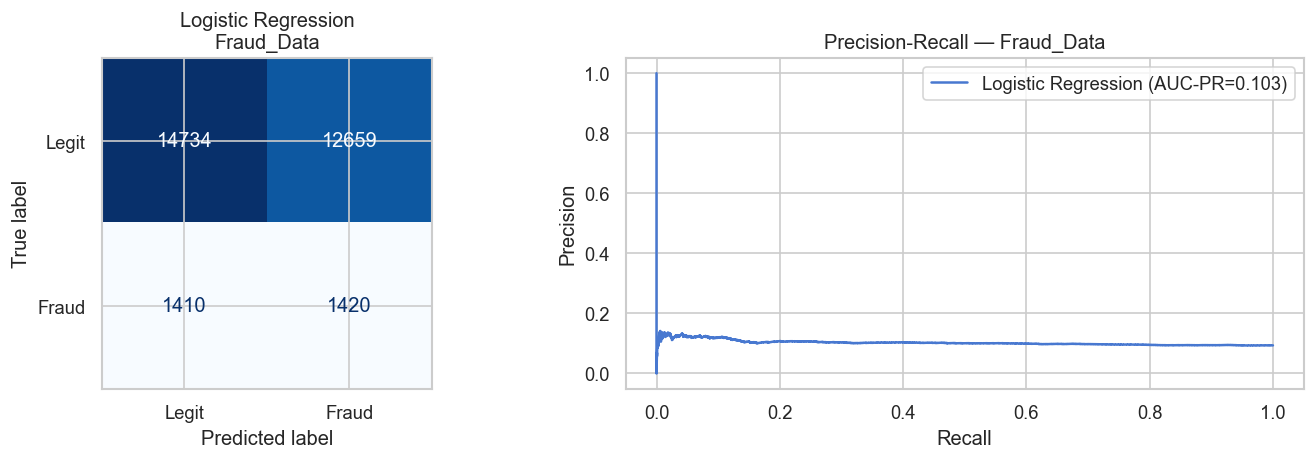

In [8]:
# --- 3.1 Train Logistic Regression — Fraud_Data ---
results = []

try:
    lr_fraud = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    )
    lr_fraud.fit(fraud_X_train, fraud_y_train)
    logger.info('Logistic Regression trained on Fraud_Data.')
except Exception as e:
    logger.error(f'LR training failed on Fraud_Data: {e}')
    raise

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
res = evaluate_model(lr_fraud, fraud_X_test, fraud_y_test,
                     'Logistic Regression', 'Fraud_Data',
                     ax_cm=axes[0], ax_pr=axes[1])
results.append(res)
plt.tight_layout()
plt.show()

2026-06-13 19:08:34,440 — INFO — Logistic Regression trained on CreditCard.
2026-06-13 19:08:34,766 — INFO — [CreditCard] Logistic Regression — F1: 0.0972 | AUC-PR: 0.6819



  Logistic Regression | CreditCard
  F1-Score : 0.0972
  AUC-PR   : 0.6819

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9730    0.9862     56651
           1     0.0515    0.8737    0.0972        95

    accuracy                         0.9728     56746
   macro avg     0.5256    0.9233    0.5417     56746
weighted avg     0.9982    0.9728    0.9847     56746



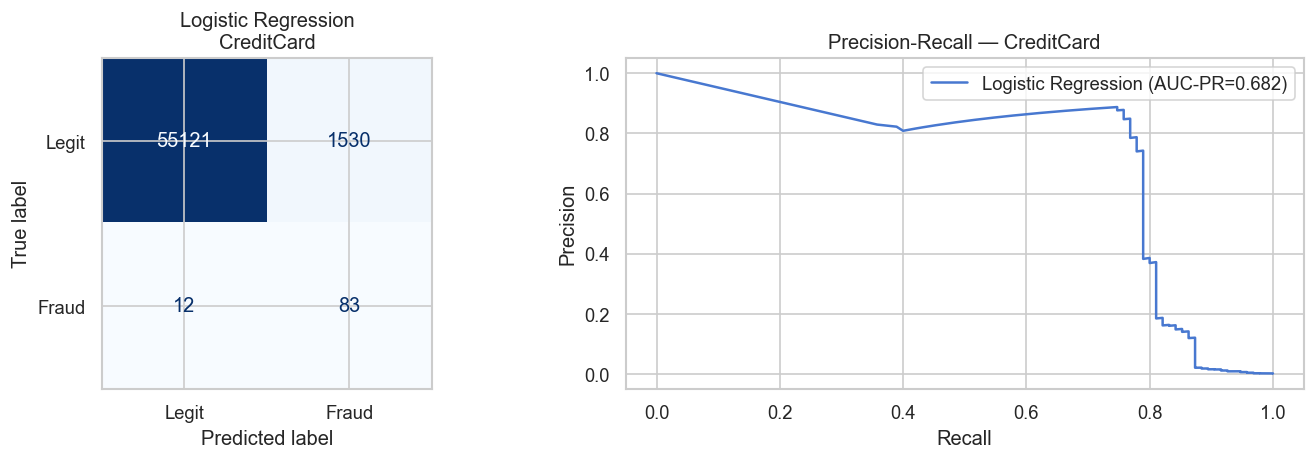

In [9]:
# --- 3.2 Train Logistic Regression — CreditCard ---
try:
    lr_cc = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    )
    lr_cc.fit(cc_X_train, cc_y_train)
    logger.info('Logistic Regression trained on CreditCard.')
except Exception as e:
    logger.error(f'LR training failed on CreditCard: {e}')
    raise

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
res = evaluate_model(lr_cc, cc_X_test, cc_y_test,
                     'Logistic Regression', 'CreditCard',
                     ax_cm=axes[0], ax_pr=axes[1])
results.append(res)
plt.tight_layout()
plt.show()